# Visualización de Cambios de Esquema - Capa Silver

## Descripción

Este notebook visualiza los resultados del análisis de **detección de cambios de esquema** realizado sobre los datasets del **NYC Taxi & Limousine Commission (TLC)**.

A partir de los reportes generados en formato **JSON**, se analiza la evolución de la estructura de los datos entre **2023 y 2025**, permitiendo identificar modificaciones que puedan afectar los procesos de integración y transformación hacia la **capa Silver**.

---

## Objetivos

- Visualizar los cambios de esquema entre los distintos años analizados.
- Identificar columnas agregadas, eliminadas o modificadas.
- Detectar cambios en los tipos de datos de los atributos.
- Evaluar la estabilidad de los esquemas para facilitar su unificación.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Origen** | Reportes generados por `detect_schema_changes.py`. |
| **Ubicación** | `data/silver/schema_detection/_reports/` |
| **Cobertura temporal** | 2023, 2024 y 2025. |
| **Datasets** | Yellow Taxi, Green Taxi, FHV y FHVHV. |

---

> **Resultado esperado:** Identificar las diferencias estructurales entre los datasets y establecer una estrategia de unificación de esquemas para las siguientes etapas del pipeline de datos.

In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colores institucionales
COLORS = {
    'yellow': '#F4D03F',
    'green': '#58D68D',
    'fhv': '#5DADE2',
    'fhvhv': '#E74C3C',
    'primary': '#2E86AB',
    'success': '#27AE60',
    'warning': '#F39C12',
    'danger': '#E74C3C',
    'excluded': '#95A5A6'
}

# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
REPORTS_DIR = ROOT_DIR / "data" / "silver" / "schema_detection" / "_reports"

print("=" * 80)
print(" VISUALIZACIÓN - DETECCIÓN DE CAMBIOS DE ESQUEMA")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Reportes: {REPORTS_DIR}")

if not REPORTS_DIR.exists():
    print("\n❌ ERROR: No se encontraron reportes.")
    print("   Ejecuta primero: 02_detect_schema_changes.py")
    exit()

 VISUALIZACIÓN - DETECCIÓN DE CAMBIOS DE ESQUEMA
 Fecha: 2026-07-17 01:18:17
 Reportes: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\schema_detection\_reports


In [4]:
# ============================================================
# CARGA DE REPORTES
# ============================================================

YEARS = [2023, 2024, 2025]
TAXI_TYPES = ['yellow', 'green', 'fhv', 'fhvhv']
EXCLUDED_TYPES = ['fhvhv']

def load_report(taxi_type):
    """Carga un reporte de cambios de esquema"""
    path = REPORTS_DIR / f"{taxi_type}_schema_changes.json"
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_reports():
    """Carga todos los reportes disponibles"""
    reports = {}
    for taxi_type in TAXI_TYPES:
        report = load_report(taxi_type)
        if report:
            reports[taxi_type] = report
    return reports

print(" Cargando reportes...")
ALL_REPORTS = load_all_reports()

print(f" Reportes cargados: {len(ALL_REPORTS)}")

print("\n Disponibilidad de reportes:")
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        report = ALL_REPORTS[taxi_type]
        yoy = report.get('year_over_year', {})
        total_changes = yoy.get('total_changes', 0) if yoy else 0
        status = "✅" if total_changes == 0 else "⚠️"
        excluded = " (EXCLUIDO)" if taxi_type in EXCLUDED_TYPES else ""
        print(f"   {status} {taxi_type.upper()}{excluded}: {total_changes} cambios detectados")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

 Cargando reportes...
 Reportes cargados: 4

 Disponibilidad de reportes:
   ⚠️ YELLOW: 2 cambios detectados
   ⚠️ GREEN: 2 cambios detectados
   ⚠️ FHV: 1 cambios detectados
   ⚠️ FHVHV (EXCLUIDO): 2 cambios detectados


 1. RESUMEN GENERAL DE CAMBIOS DE ESQUEMA

 Tabla Resumen:
  Tipo  Cambios Año-Año  Cambios Mes-Mes  Total Cambios    Estado
YELLOW                2                1              3    ACTIVO
 GREEN                2                1              3    ACTIVO
   FHV                1                1              2    ACTIVO
 FHVHV                2                1              3  EXCLUIDO


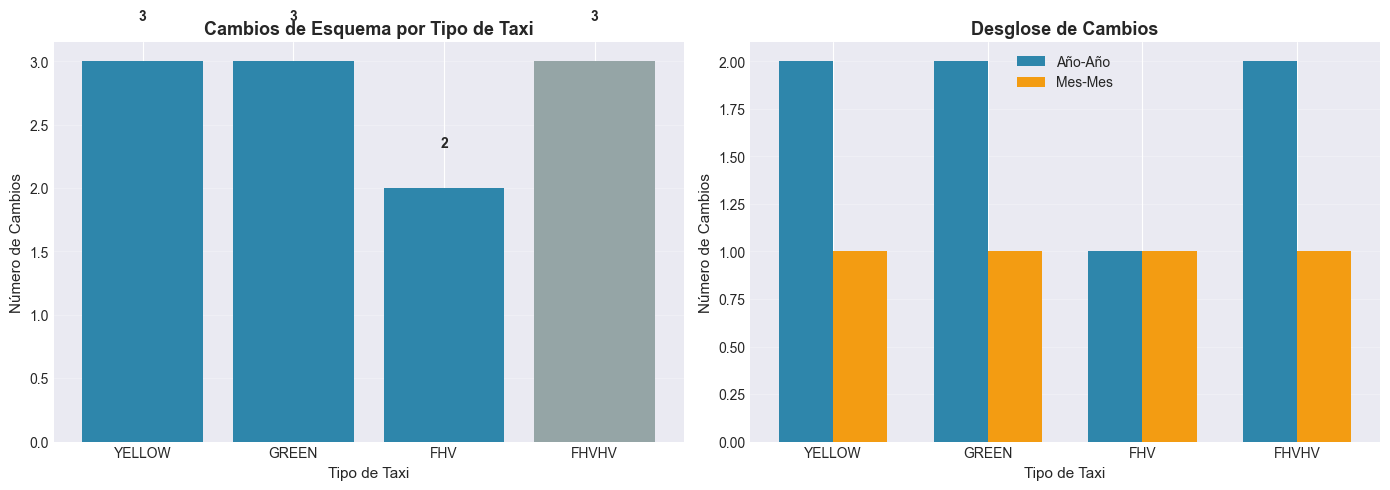


💡 CONCLUSIONES:
   ⚠️ Se detectaron 11 cambios totales
   📌 Mayor cantidad de cambios: YELLOW (3 cambios)


In [7]:
# ============================================================
# 1. RESUMEN GENERAL DE CAMBIOS
# ============================================================

print("=" * 80)
print(" 1. RESUMEN GENERAL DE CAMBIOS DE ESQUEMA")
print("=" * 80)

summary_data = []
for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    monthly = report.get('month_over_month', {})
    
    # Contar cambios año-a-año
    yoy_changes = 0
    if yoy:
        yoy_changes = yoy.get('total_changes', 0)
        years = yoy.get('years', [])
    
    # Contar cambios mes-a-mes
    monthly_changes = 0
    monthly_total = 0
    for year, month_data in monthly.items():
        monthly_changes += month_data.get('total_changes', 0)
        monthly_total += len(month_data.get('changes', []))
    
    is_excluded = taxi_type in EXCLUDED_TYPES
    summary_data.append({
        'Tipo': taxi_type.upper(),
        'Cambios Año-Año': yoy_changes,
        'Cambios Mes-Mes': monthly_changes,
        'Total Cambios': yoy_changes + monthly_changes,
        'Estado': ' EXCLUIDO' if is_excluded else ' ACTIVO'
    })

df_summary = pd.DataFrame(summary_data)

print("\n Tabla Resumen:")
print(df_summary.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cambios por tipo
ax1 = axes[0]
colors = [COLORS['excluded'] if 'EXCLUIDO' in row['Estado'] else COLORS['primary'] 
          for _, row in df_summary.iterrows()]
bars = ax1.bar(df_summary['Tipo'], df_summary['Total Cambios'], color=colors)
ax1.set_title('Cambios de Esquema por Tipo de Taxi', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tipo de Taxi', fontsize=11)
ax1.set_ylabel('Número de Cambios', fontsize=11)
ax1.grid(axis='y', alpha=0.25)

for bar, val in zip(bars, df_summary['Total Cambios']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Desglose de cambios
ax2 = axes[1]
x = np.arange(len(df_summary['Tipo']))
width = 0.35

bars1 = ax2.bar(x - width/2, df_summary['Cambios Año-Año'], width, 
                label='Año-Año', color=COLORS['primary'])
bars2 = ax2.bar(x + width/2, df_summary['Cambios Mes-Mes'], width,
                label='Mes-Mes', color=COLORS['warning'])

ax2.set_title('Desglose de Cambios', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tipo de Taxi', fontsize=11)
ax2.set_ylabel('Número de Cambios', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(df_summary['Tipo'])
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
if df_summary['Total Cambios'].sum() == 0:
    print("   ✅ Esquemas estables - Sin cambios detectados")
else:
    print(f"   ⚠️ Se detectaron {df_summary['Total Cambios'].sum()} cambios totales")
    max_changes = df_summary.loc[df_summary['Total Cambios'].idxmax()]
    print(f"   📌 Mayor cantidad de cambios: {max_changes['Tipo']} ({max_changes['Total Cambios']} cambios)")

 2. ANÁLISIS DE CAMBIOS AÑO-AÑO

 YELLOW - Comparación 2023-2026
   Total cambios: 2

   📌 2023 → 2024:
      + Nuevas columnas: Airport_fee
      - Columnas eliminadas: airport_fee
      * VendorID: bigint → int
      * RatecodeID: double → bigint
      * PULocationID: bigint → int
      * DOLocationID: bigint → int
      * passenger_count: double → bigint

   📌 2024 → 2025:
      + Nuevas columnas: cbd_congestion_fee

 GREEN - Comparación 2023-2026
   Total cambios: 2

   📌 2023 → 2024:
      * payment_type: double → bigint
      * trip_type: double → bigint
      * RatecodeID: double → bigint
      * VendorID: bigint → int
      * PULocationID: bigint → int
      * passenger_count: double → bigint
      * ehail_fee: int → double
      * DOLocationID: bigint → int

   📌 2024 → 2025:
      + Nuevas columnas: cbd_congestion_fee

 FHV - Comparación 2023-2026
   Total cambios: 1

   📌 2023 → 2024:
      * DOlocationID: double → bigint
      * PUlocationID: double → bigint
      * SR_Flag

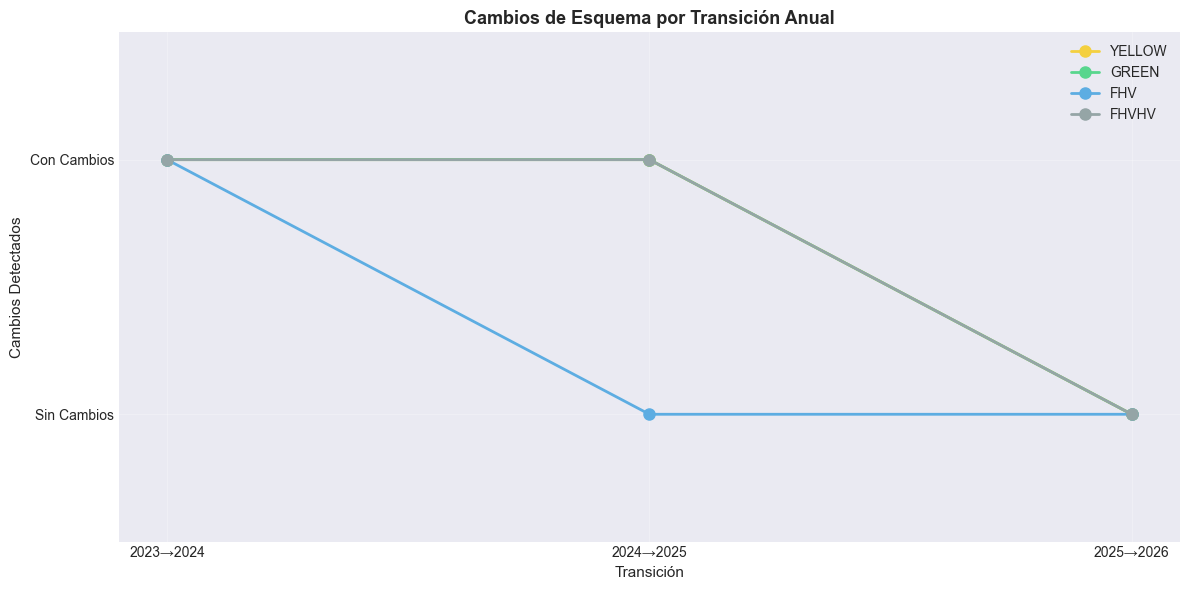

In [9]:
# ============================================================
# 2. ANÁLISIS DE CAMBIOS POR AÑO (AÑO-AÑO)
# ============================================================

print("=" * 80)
print(" 2. ANÁLISIS DE CAMBIOS AÑO-AÑO")
print("=" * 80)

for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    
    if not yoy:
        print(f"\n⚠️ {taxi_type.upper()}: Sin datos de comparación año-año")
        continue
    
    years = yoy.get('years', [])
    changes = yoy.get('changes', [])
    total_changes = yoy.get('total_changes', 0)
    
    print(f"\n {taxi_type.upper()} - Comparación {years[0]}-{years[-1]}")
    print(f"   Total cambios: {total_changes}")
    
    if total_changes == 0:
        print("    Esquema estable - Sin cambios detectados")
        continue
    
    # Mostrar detalles de cambios
    for change in changes:
        if change.get('has_changes', False):
            print(f"\n   📌 {change['from']} → {change['to']}:")
            
            if change.get('new_columns'):
                print(f"      + Nuevas columnas: {', '.join(change['new_columns'])}")
            
            if change.get('removed_columns'):
                print(f"      - Columnas eliminadas: {', '.join(change['removed_columns'])}")
            
            if change.get('type_changes'):
                for tc in change['type_changes']:
                    print(f"      * {tc['column']}: {tc['previous_type']} → {tc['current_type']}")

# Visualización consolidada
print("\n Evolución de cambios por tipo:")
fig, ax = plt.subplots(figsize=(12, 6))

for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    if not yoy:
        continue
    
    years = yoy.get('years', [])
    changes = yoy.get('changes', [])
    
    # Contar cambios por transición
    transition_labels = []
    change_counts = []
    
    for i, change in enumerate(changes):
        if i < len(years) - 1:
            label = f"{years[i]}→{years[i+1]}"
            transition_labels.append(label)
            change_counts.append(1 if change.get('has_changes', False) else 0)
    
    if transition_labels:
        color = COLORS['excluded'] if taxi_type in EXCLUDED_TYPES else COLORS.get(taxi_type, COLORS['primary'])
        ax.plot(transition_labels, change_counts, marker='o', linewidth=2, 
                markersize=8, label=taxi_type.upper(), color=color)

ax.set_title('Cambios de Esquema por Transición Anual', fontsize=13, fontweight='bold')
ax.set_xlabel('Transición', fontsize=11)
ax.set_ylabel('Cambios Detectados', fontsize=11)
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Sin Cambios', 'Con Cambios'])
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

 4. ANÁLISIS DE CAMBIOS DE TIPO DE DATOS

 YELLOW: 5 cambios de tipo
   • VendorID: bigint → int (2023→2024)
   • RatecodeID: double → bigint (2023→2024)
   • PULocationID: bigint → int (2023→2024)
   • DOLocationID: bigint → int (2023→2024)
   • passenger_count: double → bigint (2023→2024)

 GREEN: 8 cambios de tipo
   • payment_type: double → bigint (2023→2024)
   • trip_type: double → bigint (2023→2024)
   • RatecodeID: double → bigint (2023→2024)
   • VendorID: bigint → int (2023→2024)
   • PULocationID: bigint → int (2023→2024)
   ... y 3 cambios más

 FHV: 3 cambios de tipo
   • DOlocationID: double → bigint (2023→2024)
   • PUlocationID: double → bigint (2023→2024)
   • SR_Flag: int → bigint (2023→2024)

 FHVHV: 2 cambios de tipo
   • PULocationID: bigint → int (2023→2024)
   • DOLocationID: bigint → int (2023→2024)


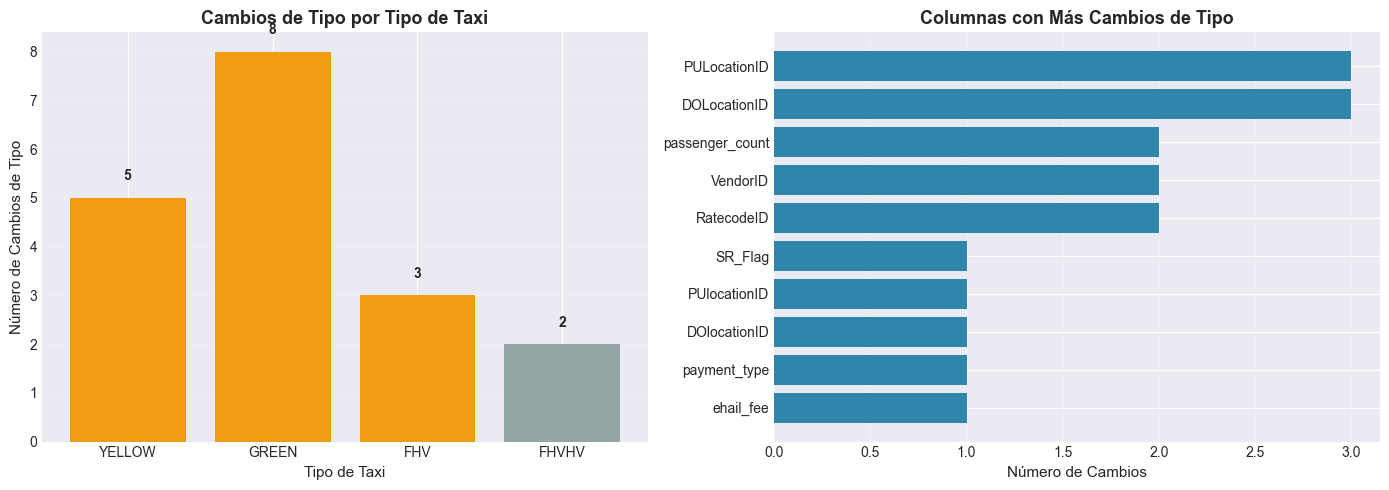

In [11]:
# ============================================================
# 4. ANÁLISIS DE CAMBIOS DE TIPO DE DATOS
# ============================================================

print("=" * 80)
print(" 4. ANÁLISIS DE CAMBIOS DE TIPO DE DATOS")
print("=" * 80)

all_type_changes = {}

for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    
    if not yoy:
        continue
    
    type_changes = []
    for change in yoy.get('changes', []):
        for tc in change.get('type_changes', []):
            type_changes.append({
                'columna': tc['column'],
                'de': tc['previous_type'],
                'a': tc['current_type'],
                'transicion': f"{change['from']}→{change['to']}"
            })
    
    if type_changes:
        all_type_changes[taxi_type] = type_changes
        
        print(f"\n {taxi_type.upper()}: {len(type_changes)} cambios de tipo")
        for tc in type_changes[:5]:  # Mostrar primeros 5
            print(f"   • {tc['columna']}: {tc['de']} → {tc['a']} ({tc['transicion']})")
        if len(type_changes) > 5:
            print(f"   ... y {len(type_changes) - 5} cambios más")
    else:
        print(f"\n {taxi_type.upper()}: Sin cambios de tipo detectados")

# Visualización
if all_type_changes:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Cantidad de cambios por tipo
    ax1 = axes[0]
    tipos = list(all_type_changes.keys())
    cantidades = [len(changes) for changes in all_type_changes.values()]
    colors = [COLORS['warning'] if t not in EXCLUDED_TYPES else COLORS['excluded'] 
              for t in tipos]
    bars = ax1.bar([t.upper() for t in tipos], cantidades, color=colors)
    ax1.set_title('Cambios de Tipo por Tipo de Taxi', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Tipo de Taxi', fontsize=11)
    ax1.set_ylabel('Número de Cambios de Tipo', fontsize=11)
    ax1.grid(axis='y', alpha=0.25)
    
    for bar, val in zip(bars, cantidades):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{int(val)}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 2: Columnas más afectadas
    ax2 = axes[1]
    col_counter = {}
    for changes in all_type_changes.values():
        for tc in changes:
            col_counter[tc['columna']] = col_counter.get(tc['columna'], 0) + 1
    
    if col_counter:
        df_cols = pd.DataFrame(list(col_counter.items()), columns=['Columna', 'Veces'])
        df_cols = df_cols.sort_values('Veces', ascending=True).tail(10)
        
        colors = [COLORS['primary'] for _ in range(len(df_cols))]
        ax2.barh(df_cols['Columna'], df_cols['Veces'], color=colors)
        ax2.set_title('Columnas con Más Cambios de Tipo', fontsize=13, fontweight='bold')
        ax2.set_xlabel('Número de Cambios', fontsize=11)
        ax2.grid(axis='x', alpha=0.25)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Sin cambios de tipo de datos detectados")

 5. ESTABILIDAD DEL ESQUEMA POR TIPO

 Estabilidad por Tipo de Taxi:
  Tipo  Estabilidad Año (%)  Estabilidad Mes (%)  Estabilidad Global (%)   Estado
YELLOW                66.67                99.25                   82.96   ACTIVO
 GREEN                66.67                99.25                   82.96   ACTIVO
   FHV                83.33                99.23                   91.28   ACTIVO
 FHVHV                66.67                99.25                   82.96 EXCLUIDO


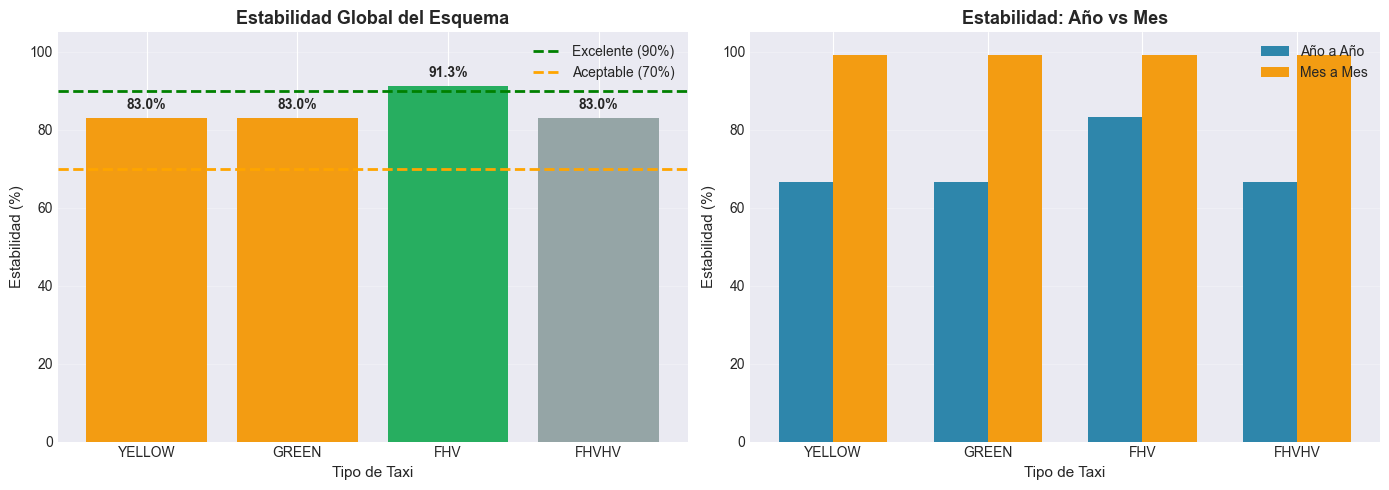


💡 CONCLUSIONES DE ESTABILIDAD:
   ⚠️ YELLOW: Esquema razonablemente estable (83.0%)
   ⚠️ GREEN: Esquema razonablemente estable (83.0%)
   ✅ FHV: Esquema muy estable (91.3%)
   🚫 FHVHV: Excluido del pipeline


In [15]:
# ============================================================
# 5. ESTABILIDAD DEL ESQUEMA
# ============================================================

print("=" * 80)
print(" 5. ESTABILIDAD DEL ESQUEMA POR TIPO")
print("=" * 80)

stability_data = []
for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    monthly = report.get('month_over_month', {})
    
    # Calcular métricas de estabilidad
    total_years = len(yoy.get('years', []))
    yoy_changes = yoy.get('total_changes', 0)
    
    total_months = 0
    monthly_changes = 0
    for year, month_data in monthly.items():
        total_months += len(month_data.get('months', []))
        monthly_changes += month_data.get('total_changes', 0)
    
    # Puntuación de estabilidad (0-100)
    if total_years > 1:
        year_stability = max(0, 100 - (yoy_changes / (total_years - 1) * 50))
    else:
        year_stability = 100
    
    if total_months > 1:
        month_stability = max(0, 100 - (monthly_changes / (total_months - 1) * 30))
    else:
        month_stability = 100
    
    overall_stability = (year_stability + month_stability) / 2
    
    is_excluded = taxi_type in EXCLUDED_TYPES
    stability_data.append({
        'Tipo': taxi_type.upper(),
        'Estabilidad Año (%)': year_stability,
        'Estabilidad Mes (%)': month_stability,
        'Estabilidad Global (%)': overall_stability,
        'Estado': 'EXCLUIDO' if is_excluded else 'ACTIVO'
    })

df_stability = pd.DataFrame(stability_data)

print("\n Estabilidad por Tipo de Taxi:")
print(df_stability.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Estabilidad global
ax1 = axes[0]
colors = [COLORS['excluded'] if row['Estado'] == 'EXCLUIDO' 
          else COLORS['success'] if row['Estabilidad Global (%)'] >= 90
          else COLORS['warning'] if row['Estabilidad Global (%)'] >= 70
          else COLORS['danger']
          for _, row in df_stability.iterrows()]

bars = ax1.bar(df_stability['Tipo'], df_stability['Estabilidad Global (%)'], color=colors)
ax1.axhline(y=90, color='green', linestyle='--', linewidth=2, label='Excelente (90%)')
ax1.axhline(y=70, color='orange', linestyle='--', linewidth=2, label='Aceptable (70%)')
ax1.set_title('Estabilidad Global del Esquema', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tipo de Taxi', fontsize=11)
ax1.set_ylabel('Estabilidad (%)', fontsize=11)
ax1.legend(loc='best')
ax1.grid(axis='y', alpha=0.25)
ax1.set_ylim(0, 105)

for bar, val in zip(bars, df_stability['Estabilidad Global (%)']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Comparativa Año vs Mes
ax2 = axes[1]
x = np.arange(len(df_stability['Tipo']))
width = 0.35

bars1 = ax2.bar(x - width/2, df_stability['Estabilidad Año (%)'], width,
                label='Año a Año', color=COLORS['primary'])
bars2 = ax2.bar(x + width/2, df_stability['Estabilidad Mes (%)'], width,
                label='Mes a Mes', color=COLORS['warning'])

ax2.set_title('Estabilidad: Año vs Mes', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tipo de Taxi', fontsize=11)
ax2.set_ylabel('Estabilidad (%)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(df_stability['Tipo'])
ax2.legend(loc='best')
ax2.grid(axis='y', alpha=0.25)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES DE ESTABILIDAD:")
for _, row in df_stability.iterrows():
    if row['Estado'] == 'EXCLUIDO':
        print(f"   🚫 {row['Tipo']}: Excluido del pipeline")
    elif row['Estabilidad Global (%)'] >= 90:
        print(f"   ✅ {row['Tipo']}: Esquema muy estable ({row['Estabilidad Global (%)']:.1f}%)")
    elif row['Estabilidad Global (%)'] >= 70:
        print(f"   ⚠️ {row['Tipo']}: Esquema razonablemente estable ({row['Estabilidad Global (%)']:.1f}%)")
    else:
        print(f"   ❌ {row['Tipo']}: Esquema inestable ({row['Estabilidad Global (%)']:.1f}%) - Requiere revisión")

In [17]:
# ============================================================
# 6. RESUMEN EJECUTIVO FINAL
# ============================================================

print("=" * 80)
print(" 6. RESUMEN EJECUTIVO - DETECCIÓN DE CAMBIOS DE ESQUEMA")
print("=" * 80)

# Estadísticas globales
total_types = len(ALL_REPORTS)
types_with_changes = 0
total_yoy_changes = 0
total_monthly_changes = 0

for taxi_type, report in ALL_REPORTS.items():
    yoy = report.get('year_over_year', {})
    if yoy.get('total_changes', 0) > 0:
        types_with_changes += 1
    total_yoy_changes += yoy.get('total_changes', 0)
    
    monthly = report.get('month_over_month', {})
    for year, month_data in monthly.items():
        total_monthly_changes += month_data.get('total_changes', 0)

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Tipos analizados: {total_types}")
print(f"   • Tipos con cambios: {types_with_changes}")
print(f"   • Cambios año-a-año: {total_yoy_changes}")
print(f"   • Cambios mes-a-mes: {total_monthly_changes}")
print(f"   • Total cambios: {total_yoy_changes + total_monthly_changes}")

print(f"\n RECOMENDACIONES PARA UNIFIED SCHEMA:")

# Identificar tipos estables
stable_types = df_stability[df_stability['Estabilidad Global (%)'] >= 85]
if not stable_types.empty:
    print(f"   • Usar como referencia: {', '.join(stable_types['Tipo'].tolist())}")

# Identificar tipos con cambios
unstable_types = df_stability[df_stability['Estabilidad Global (%)'] < 70]
if not unstable_types.empty:
    print(f"   • Requieren atención: {', '.join(unstable_types['Tipo'].tolist())}")

# Recomendaciones generales
print(f"\n ACCIONES RECOMENDADAS:")

if total_yoy_changes == 0 and total_monthly_changes == 0:
    print("    Esquemas estables - Se puede proceder con unificación")
else:
    if total_yoy_changes > 0:
        print(f"   • Revisar {total_yoy_changes} cambios año-a-año")
    if total_monthly_changes > 0:
        print(f"   • Revisar {total_monthly_changes} cambios mes-a-mes")
    print("   • Definir estrategia de manejo de cambios en unified schema")
    print("   • Considerar versionado de esquemas")

# Tipos excluidos
excluded_types = [t for t in TAXI_TYPES if t in EXCLUDED_TYPES]
if any(t in ALL_REPORTS for t in excluded_types):
    print(f"\n TIPOS EXCLUIDOS:")
    for t in excluded_types:
        if t in ALL_REPORTS:
            print(f"   • {t.upper()}: Excluido por volumen masivo")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Reportes: {REPORTS_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

 6. RESUMEN EJECUTIVO - DETECCIÓN DE CAMBIOS DE ESQUEMA

 ESTADÍSTICAS GLOBALES:
   • Tipos analizados: 4
   • Tipos con cambios: 4
   • Cambios año-a-año: 7
   • Cambios mes-a-mes: 4
   • Total cambios: 11

 RECOMENDACIONES PARA UNIFIED SCHEMA:
   • Usar como referencia: FHV

 ACCIONES RECOMENDADAS:
   • Revisar 7 cambios año-a-año
   • Revisar 4 cambios mes-a-mes
   • Definir estrategia de manejo de cambios en unified schema
   • Considerar versionado de esquemas

 TIPOS EXCLUIDOS:
   • FHVHV: Excluido por volumen masivo

 UBICACIÓN DE ARCHIVOS:
   • Reportes: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\schema_detection\_reports
 ANÁLISIS COMPLETADO
   Fecha: 2026-07-17 01:24:51
